In [ ]:
!pip install numpy==1.26.4
!pip install esm==3.1.2
!pip install flash-attn --no-build-isolation
!pip install biopython
import sys
!{sys.executable} -m pip uninstall -y biopython
!{sys.executable} -m pip install biopython==1.83

  Using cached esm-3.1.2-py3-none-any.whl.metadata (19 kB)
  Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl.metadata (7.9 kB)
  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
  Using cached biotite-0.41.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.1 kB)
  Using cached msgpack_numpy-0.4.8-py2.py3-none-any.whl.metadata (5.0 kB)
  Using cached biopython-1.85-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached zstd-1.5.7.2-cp312-cp312-manylinux_2_14_x86_64.whl.metadata (23 kB)
  Using cached tokenizers-0.20.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached jedi-0.19.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached esm-3.1.2-py3-none-any.whl (2.4 MB)
Using cached biotite-0.41.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (39.0 MB)
Using cached transformers-4.46.3-py3-none-any.whl (10.0 MB)
Using cached biopython-1.85-cp312-cp3

In [ ]:
import torch
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

client = ESMC.from_pretrained("esmc_600m").to("cuda") # or "cpu"


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

esmc_600m_2024_12_v0.pth:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [ ]:
  protein = ESMProtein(sequence="AAA")
  protein_tensor = client.encode(protein)
  logits_output = client.logits(
    protein_tensor, LogitsConfig(sequence=True, return_embeddings=True, return_hidden_states=True)
  )

In [ ]:
def embed_protein(protein_seq, middle_layer = 12):
  protein = ESMProtein(sequence=protein_seq)
  protein_tensor = client.encode(protein)
  logits_output = client.logits(
    protein_tensor, LogitsConfig(sequence=True, return_embeddings=True, return_hidden_states=True)
  )
  embeddings = logits_output.embeddings.squeeze()
  logits = logits_output.hidden_states[middle_layer].squeeze()

  max = torch.max(embeddings, dim=0).values.detach().cpu().numpy()
  mean = embeddings.mean(dim=0).detach().cpu().numpy()
  max_middle = torch.max(logits,dim=0).values.float().detach().cpu().numpy()
  mean_middle = logits.mean(dim=0).float().detach().cpu().numpy()
  result = {
    #"max": max,
    "mean": mean,
    #"max_middle_layer": max_middle,
    #"mean_middle_layer": mean_middle
  }
  return result

In [ ]:
#load in xlsx
import pandas as pd
uniprotkb = pd.read_excel("/content/uniprotkb_reviewed_true_AND_reviewed_tr_2025_08_13.xlsx")
cell_value = uniprotkb.iloc[0,8]
print(cell_value)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


VARIANT 70; /note="S -> N (in dbSNP:rs11090077)"; /evidence="ECO:0000269|PubMed:15051713"; /id="VAR_072632"; VARIANT 311; /note="S -> L (in dbSNP:rs1800754)"; /evidence="ECO:0000269|PubMed:15051713"; /id="VAR_072633"; VARIANT 337; /note="C -> CS"; /evidence="ECO:0000269|PubMed:15051713"; /id="VAR_072634"; VARIANT 369..373; /note="AHMPC -> VHMPY"; /evidence="ECO:0000269|PubMed:15051713"; /id="VAR_072635"; VARIANT 383; /note="H -> R (in dbSNP:rs56127449)"; /evidence="ECO:0000269|PubMed:15051713"; /id="VAR_072636"; VARIANT 428; /note="K -> E (in dbSNP:rs2070907)"; /evidence="ECO:0000269|PubMed:15051713"; /id="VAR_072637"


In [ ]:
uniprotkb

,Entry,Entry Name,Protein names,Gene Names,Organism,Length,Sequence,Polymorphism,Natural variant
0,A0A087X1C5,CP2D7_HUMAN,Cytochrome P450 2D7 (EC 1.14.14.1),CYP2D7,Homo sapiens (Human),515,MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,POLYMORPHISM: One study shows that a rare doub...,"VARIANT 70; /note=""S -> N (in dbSNP:rs11090077..."
1,A0A0B4J2F0,PIOS1_HUMAN,Protein PIGBOS1 (PIGB opposite strand protein 1),PIGBOS1,Homo sapiens (Human),54,MFRRLTFAQLLFATVLGIAGGVYIFQPVFEQYAKDQKELKEKMQLV...,NaN,NaN
2,A0A0C5B5G6,MOTSC_HUMAN,Mitochondrial-derived peptide MOTS-c (Mitochon...,MT-RNR1,Homo sapiens (Human),16,MRWQEMGYIFYPRKLR,NaN,"VARIANT 14; /note=""K -> Q (specific to the Nor..."
3,A0A0K2S4Q6,CD3CH_HUMAN,Protein CD300H (CD300 antigen-like family memb...,CD300H,Homo sapiens (Human),201,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,POLYMORPHISM: The sequence shown in this entry...,NaN
4,A0A0U1RRE5,NBDY_HUMAN,Negative regulator of P-body association (P-bo...,NBDY LINC01420,Homo sapiens (Human),68,MGDQPCASGRSTLPPGNAREAKPPKKRCLLAPRWDYPEGTPNGGST...,NaN,NaN
...,...,...,...,...,...,...,...,...,...
20415,Q9UI25,YP002_HUMAN,Putative uncharacterized protein PRO0461,PRO0461,Homo sapiens (Human),63,MEEMSYGENSGTHVGSFSCSPQPSQQMKVLFVGNSFLLTPVLHRQP...,NaN,NaN
20416,Q9UI54,YT001_HUMAN,Putative uncharacterized protein PRO0628,PRO0628,Homo sapiens (Human),55,MESPKCLYSRITVNTAFGTKFSHISFIILFKVFLFPRITISKKTKL...,NaN,NaN
20417,Q9UI72,YE014_HUMAN,Putative uncharacterized protein PRO0255,PRO0255,Homo sapiens (Human),69,MGMALELYWLCGFRSYWPLGTNAENEGNRKENRRQMQSRNERGCNV...,NaN,NaN
20418,Q9Y3F1,TA6P_HUMAN,Putative TAP2-associated 6.5 kDa polypeptide,NaN,Homo sapiens (Human),56,MSLLWTPQILTISFVSYILSLFPSPFPSCYTSCWFETSITTEKELN...,NaN,NaN


In [ ]:
def generate_single_position_M_sequences(seq):
    results = []
    mutated = list(seq)  # original as list
    for i in range(len(mutated)):
        mutated[i] = 'M'  # mutate position i (0-based)
        mutated_sequence = ''.join(mutated)
        position_id = f"{i+1}a"  # exactly "1a", "2a", ...
        results.append({
            "step": i+1,
            "mutated_sequence": mutated_sequence,
            "mutated_position_id": position_id
        })
    return pd.DataFrame(results)

protein = uniprotkb.iloc[0,6]
protein_m = generate_single_position_M_sequences(protein)
protein_m

,step,mutated_sequence,mutated_position_id
0,1,MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,1a
1,2,MMLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,2a
2,3,MMMEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,3a
3,4,MMMMALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,4a
4,5,MMMMMLVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,5a
...,...,...,...
510,511,MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM...,511a
511,512,MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM...,512a
512,513,MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM...,513a
513,514,MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM...,514a


In [ ]:
#create the embeds then graph them
embeds = []
for row in protein_m["mutated_sequence"]:
  embeds.append(embed_protein(row, middle_layer=12))

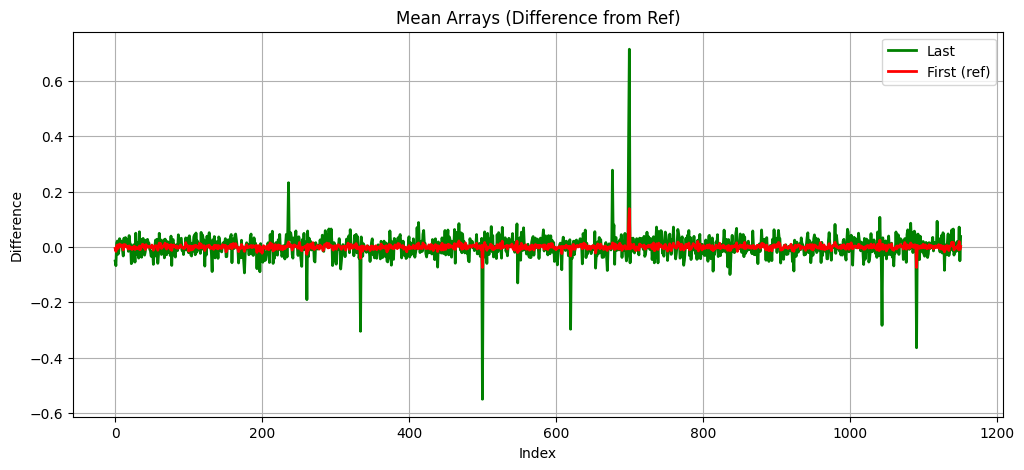

In [ ]:
import matplotlib.pyplot as plt
mean_arrays = [d["mean"] for d in embeds]
#the first sequence in mean_arrays will be the embeds for the ref sequence
ref = mean_arrays[0]
#make list of differences
diff = []
for i in mean_arrays:
  diff.append(i-ref)

plt.figure(figsize=(12, 5))
for i, j in reversed(list(enumerate(diff))):
    if i == 100:
        plt.plot(range(len(j)), j, label="First (ref)", color="red", linewidth=2)
    elif i == len(diff) - 1:
        plt.plot(range(len(j)), j, label="Last", color="green", linewidth=2)

plt.xlabel("Index")
plt.ylabel("Difference")
plt.title("Mean Arrays (Difference from Ref)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Figure out how similar proteins are given a sequence using BLOSUM then compare it to the embed graph
sequences = []
sequence1 = uniprotkb["Sequence"][0]
embed_sequence1 = embed_protein(sequence1, middle_layer=12)
for i in range(200):
  sequences.append(uniprotkb["Sequence"][i])

from Bio.Align import substitution_matrices

#Load BLOSUM62
S = substitution_matrices.load("BLOSUM62")

#Score sequences
def blosum_score(seq1, seq2, mat=S):
    return sum(mat[a, b] for a, b in zip(seq1, seq2))

scores = []
embeds = []

#get scores
for sequence2 in sequences:
  scores.append(blosum_score(sequence2, sequence1, mat=S))

#get embeds for each sequence then calculate difference
for sequence in sequences:
  embeds.append(embed_protein(sequence, middle_layer=12))

In [ ]:
mean_arrays = [d["mean"] for d in embeds]
ref_mean_array = embed_sequence1["mean"]

differences = []
for mean_array in mean_arrays:
  differences.append(mean_array-ref_mean_array)

#function to calculate cosine diff
from scipy import spatial
import numpy as np
from numpy import dot
from numpy.linalg import norm

def cosine_sim(a, b, scale_to_unit=True):
    """a = np.ravel(a).astype(float)
    b = np.ravel(b).astype(float)
    cos_sim = 1 - spatial.distance.cosine(a, b)
    if scale_to_unit:
        return (cos_sim + 1) / 2  # maps [-1,1] → [0,1]
    return cos_sim"""

    cos_sim = dot(a, b)/(norm(a)*norm(b))
    return cos_sim

cosine_diff = []
for mean_array in mean_arrays:
  cosine_diff.append(cosine_sim(ref_mean_array, mean_array))

scores.pop(0)
cosine_diff.pop(0)
print(cosine_diff)

#zip scores and cosine difference
score_cosine_sim_pairs = list(zip(scores, cosine_diff))

#zip scores and embeds as a tuple. then sort by scores from largest to smallest
score_embed_pairs = list(zip(scores, differences))

#Sort by score, descending
score_embed_pairs_sorted = sorted(score_embed_pairs, key=lambda x: x[0], reverse=True)


[0.66280735, 0.20077917, 0.79703134, 0.24631779, 0.7195006, 0.8545361, 0.59607524, 0.78375435, 0.5852738, 0.60837185, 0.7279749, 0.8619264, 0.80212986, 0.50022304, 0.6485376, 0.570516, 0.66856, 0.6607064, 0.8117262, 0.6331247, 0.8045835, 0.7653049, 0.77788484, 0.6962584, 0.57187307, 0.8751256, 0.83725864, 0.36686325, 0.51475495, 0.7716787, 0.8814837, 0.6663253, 0.4241046, 0.71138215, 0.7453441, 0.5437511, 0.6864112, 0.6743815, 0.7455041, 0.6340223, 0.8026318, 0.78364027, 0.77642447, 0.6078638, 0.5477609, 0.78178734, 0.4329381, 0.4203592, 0.7831337, 0.28864655, 0.5872004, 0.82978785, 0.8409516, 0.46185392, 0.7505757, 0.72730476, 0.72129154, 0.82142234, 0.72482085, 0.48376507, 0.75536186, 0.7617106, 0.624638, 0.7275155, 0.726132, 0.57151157, 0.8906803, 0.35224912, 0.6232431, 0.7480902, 0.7107029, 0.8165233, 0.52005816, 0.8657471, 0.74333274, 0.8325403, 0.8654819, 0.5935331, 0.73505616, 0.7270792, 0.3313399, 0.5932058, 0.74052083, 0.70716286, 0.7905493, 0.7107697, 0.5647207, 0.43853584, 0

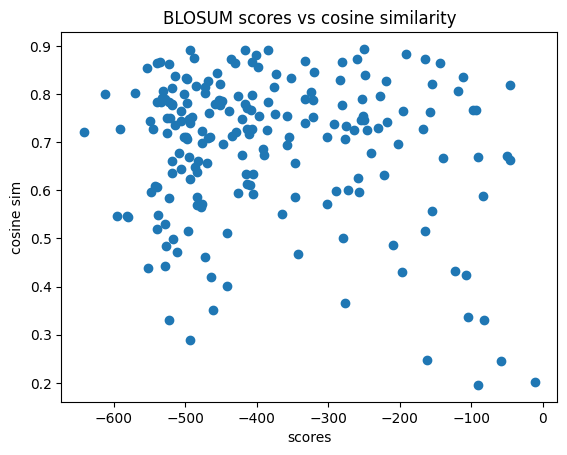

In [ ]:
#plot the zipped scores and cosine difference
x, y = zip(*score_cosine_sim_pairs)  # x = scores, y = cosine similarities

plt.scatter(x,y)
plt.xlabel("scores")
plt.ylabel("cosine sim")
plt.title("BLOSUM scores vs cosine similarity")
plt.show()

Score: -11.0
Score: -45.0
Score: -45.0
Score: -50.0
Score: -58.0


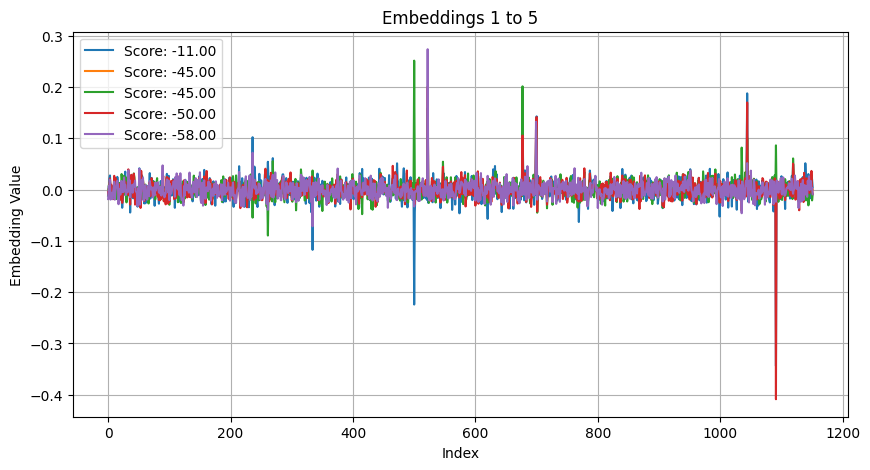

Score: -82.0
Score: -84.0
Score: -90.0
Score: -90.0
Score: -93.0


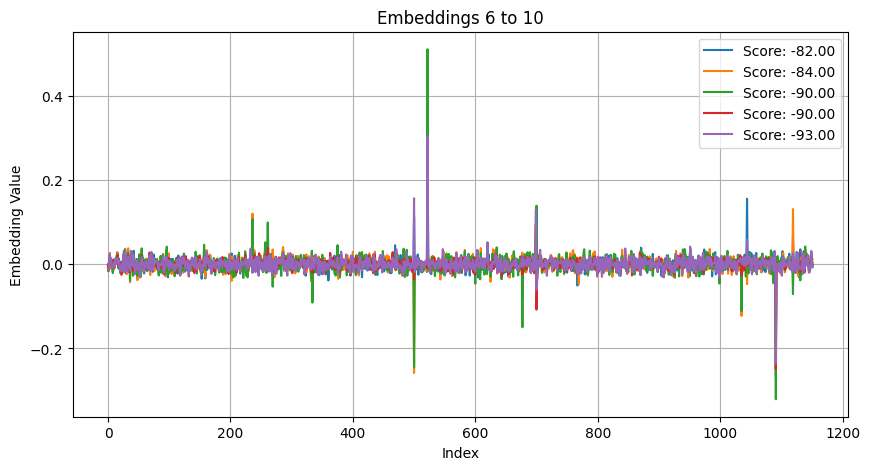

Score: -98.0
Score: -104.0
Score: -107.0
Score: -111.0
Score: -119.0


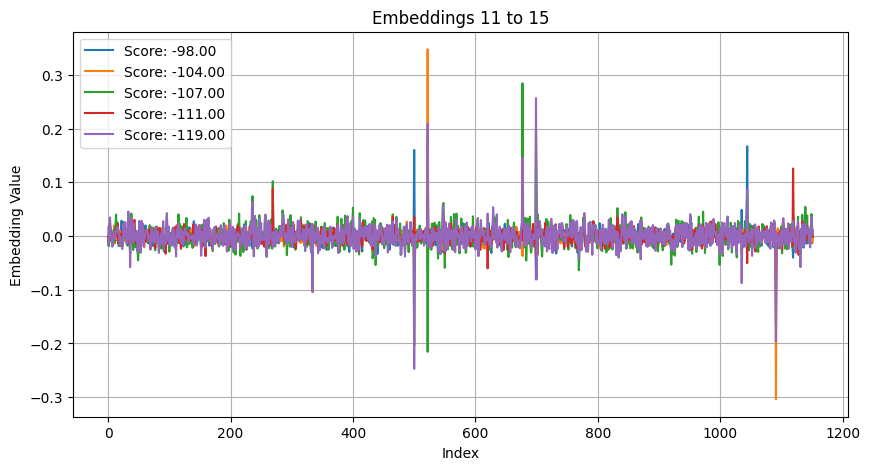

Score: -123.0
Score: -139.0
Score: -144.0
Score: -155.0
Score: -155.0


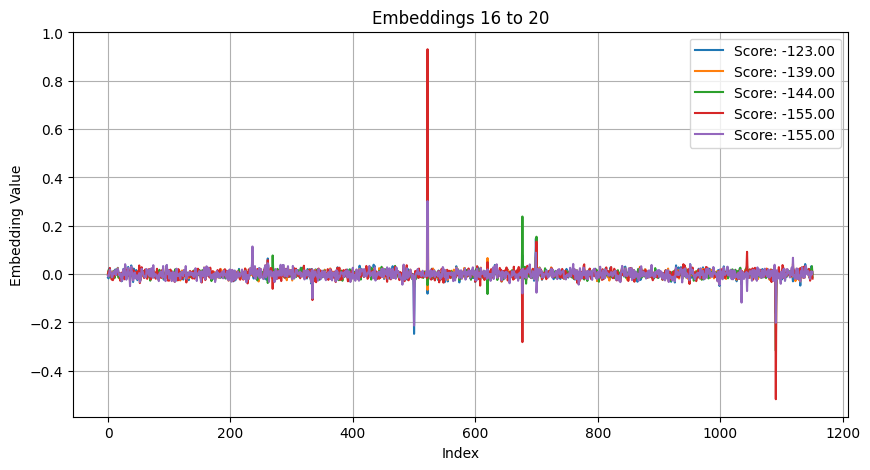

Score: -158.0
Score: -162.0
Score: -164.0
Score: -164.0
Score: -168.0


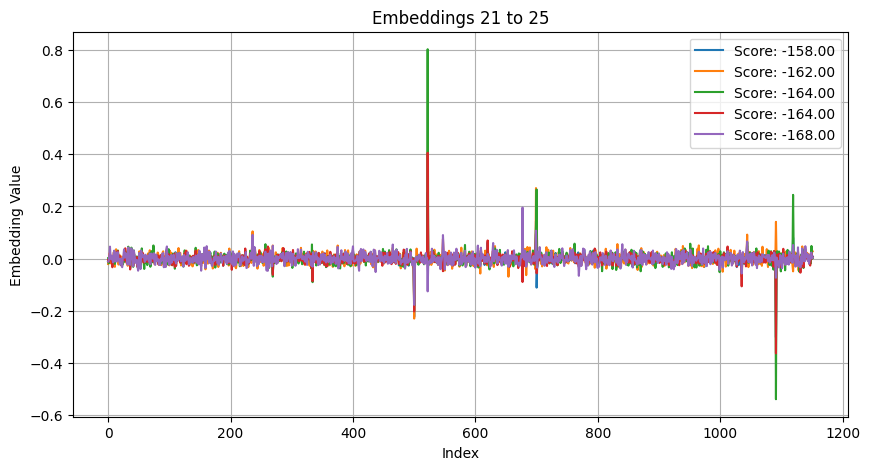

Score: -191.0
Score: -195.0
Score: -197.0
Score: -202.0
Score: -210.0


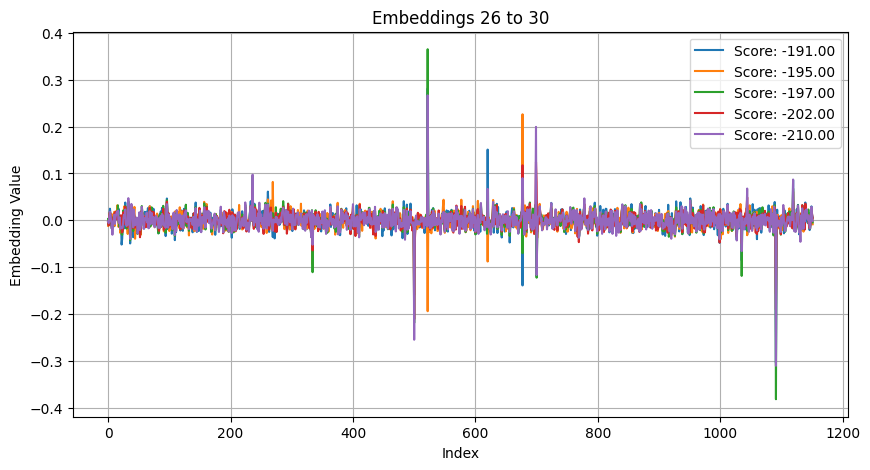

Score: -218.0
Score: -219.0
Score: -222.0
Score: -227.0
Score: -230.0


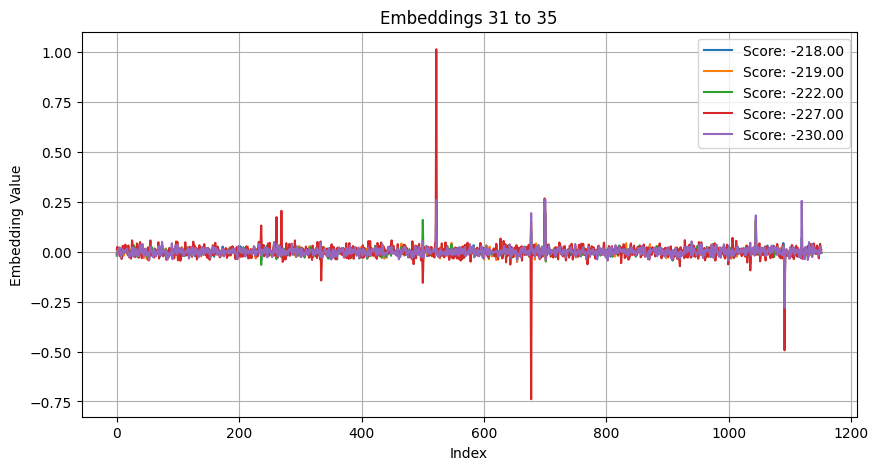

Score: -240.0
Score: -246.0
Score: -249.0
Score: -250.0
Score: -250.0


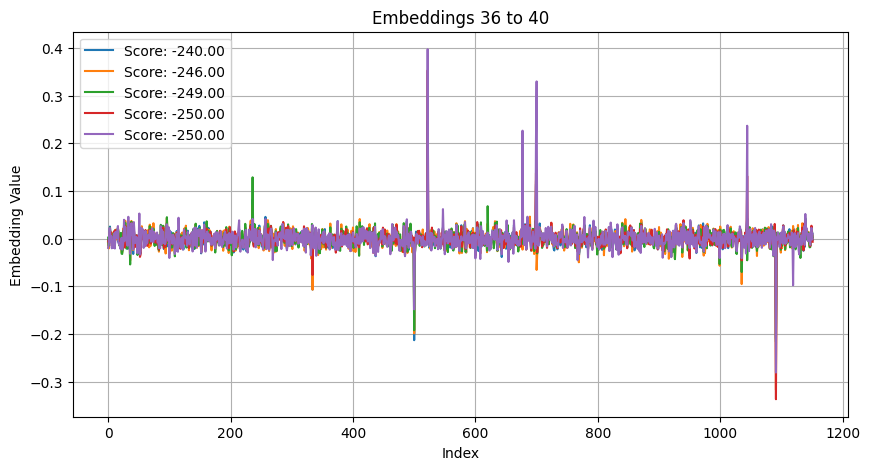

Score: -251.0
Score: -253.0
Score: -254.0
Score: -257.0
Score: -258.0


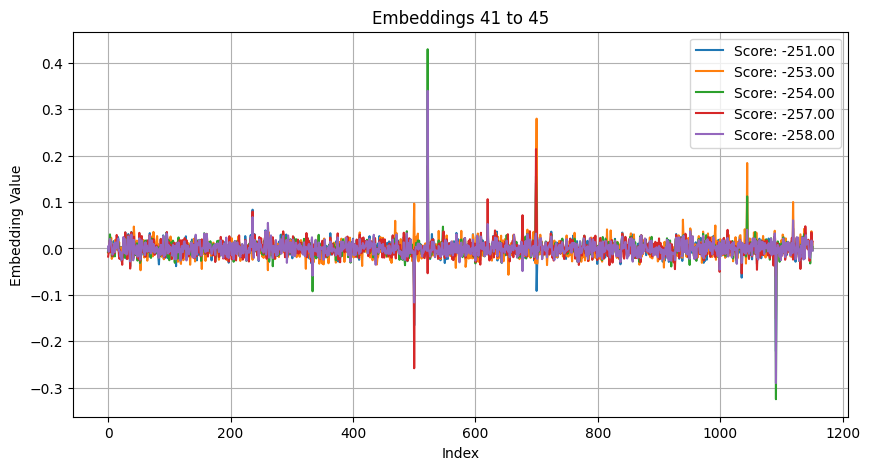

Score: -260.0
Score: -264.0
Score: -272.0
Score: -275.0
Score: -277.0


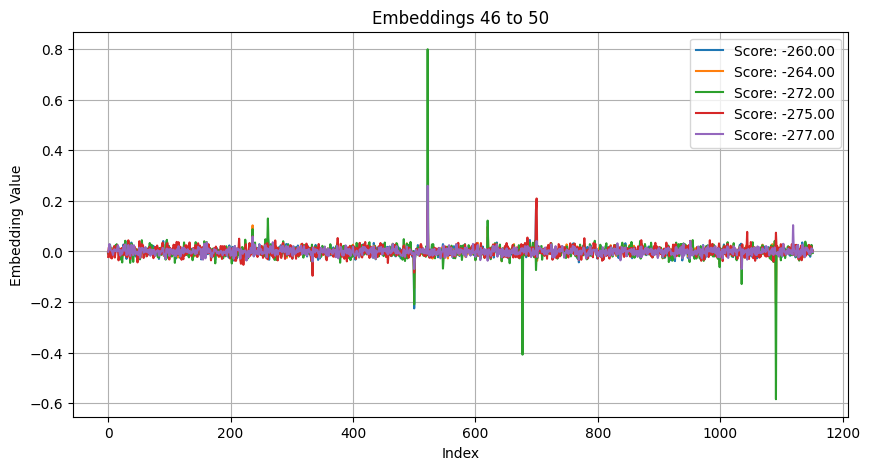

Score: -277.0
Score: -280.0
Score: -281.0
Score: -281.0
Score: -284.0


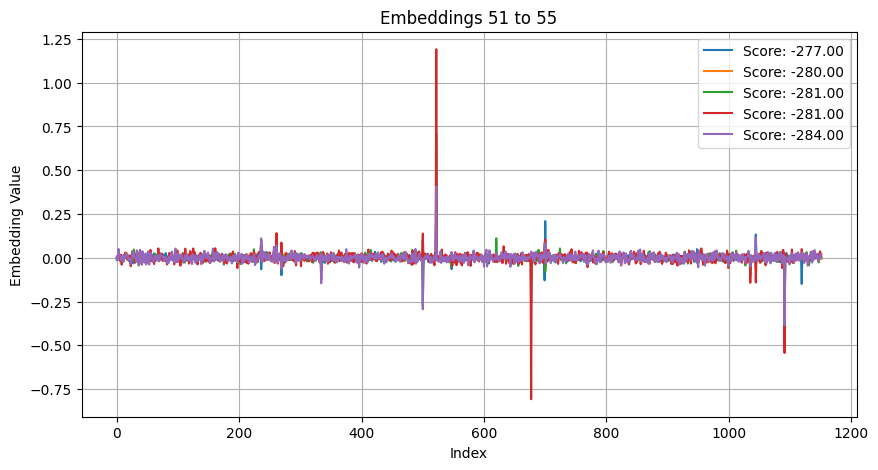

Score: -289.0
Score: -292.0
Score: -301.0
Score: -302.0
Score: -320.0


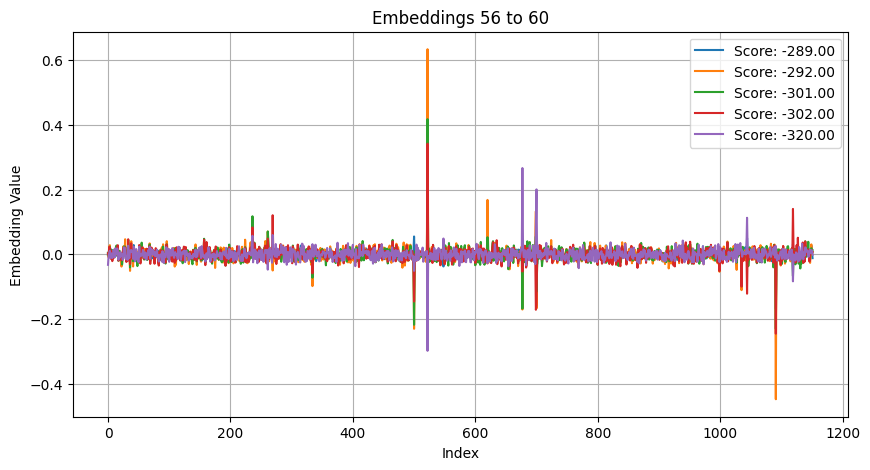

Score: -321.0
Score: -321.0
Score: -324.0
Score: -332.0
Score: -333.0


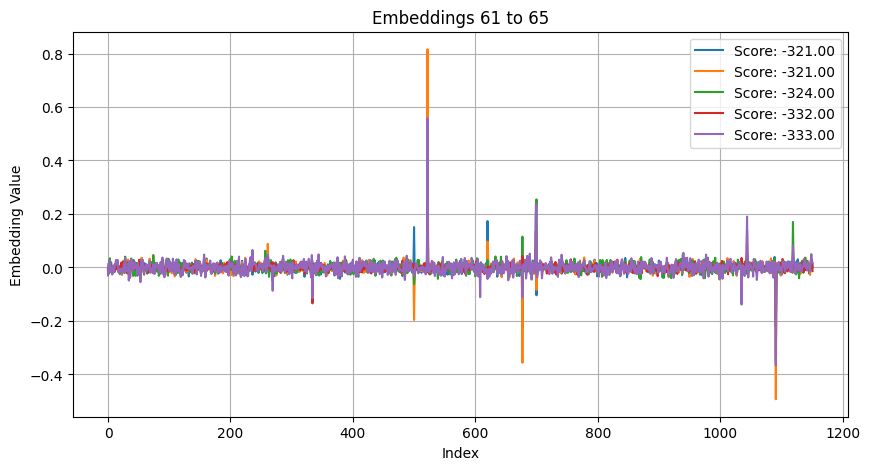

Score: -333.0
Score: -342.0
Score: -346.0
Score: -347.0
Score: -352.0


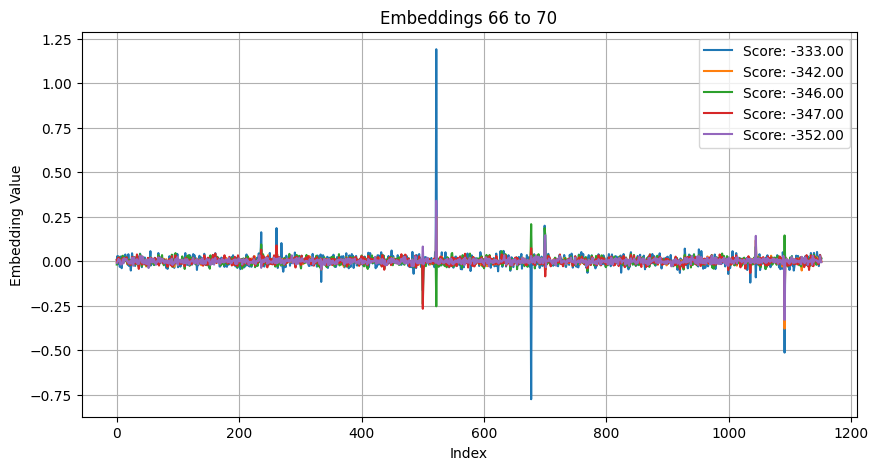

Score: -355.0
Score: -357.0
Score: -357.0
Score: -364.0
Score: -373.0


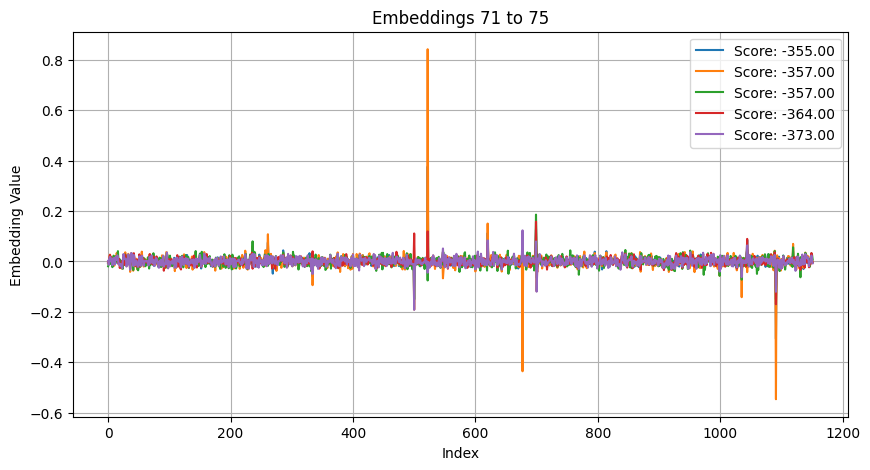

Score: -375.0
Score: -376.0
Score: -384.0
Score: -384.0
Score: -385.0


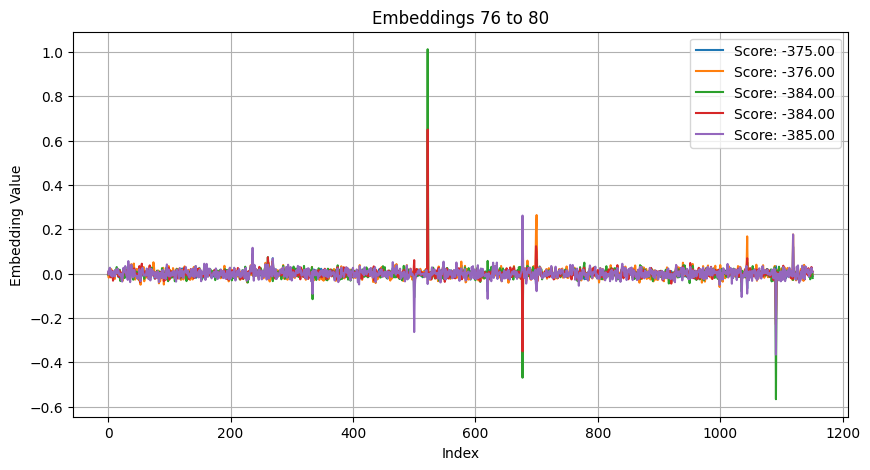

Score: -390.0
Score: -391.0
Score: -397.0
Score: -398.0
Score: -401.0


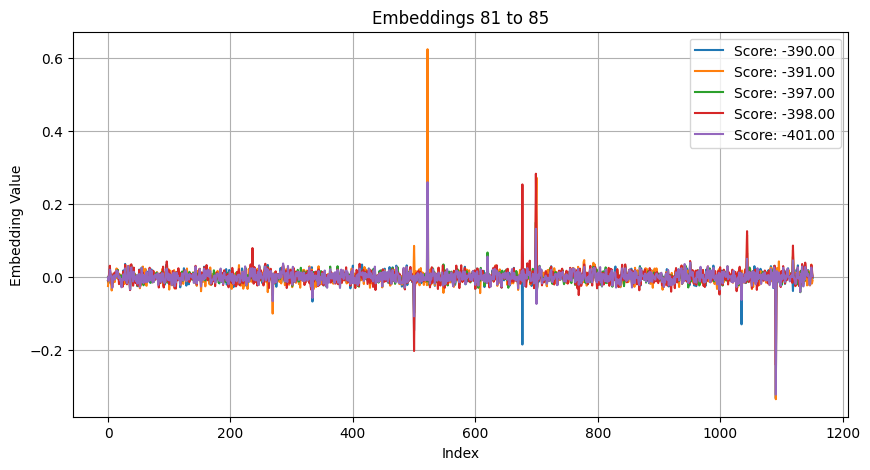

Score: -405.0
Score: -405.0
Score: -406.0
Score: -406.0
Score: -406.0


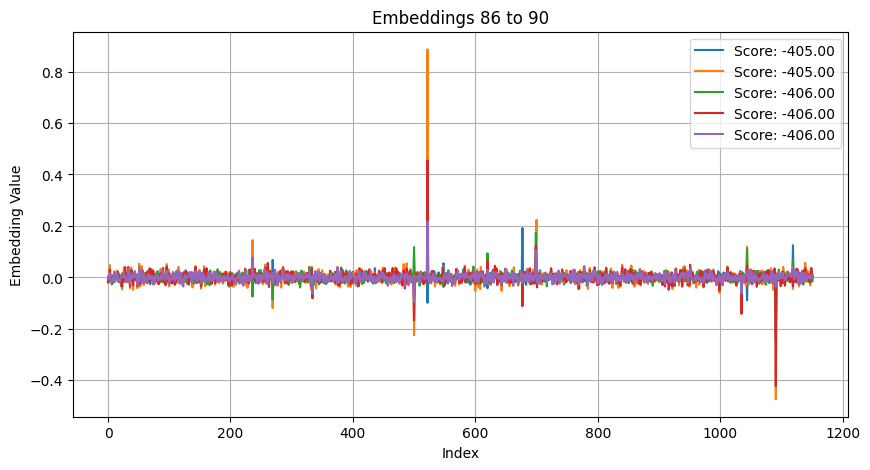

Score: -408.0
Score: -409.0
Score: -411.0
Score: -413.0
Score: -414.0


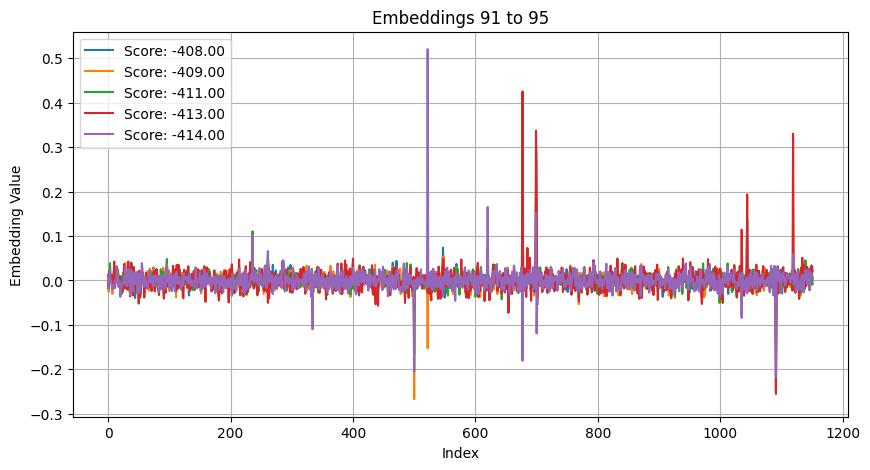

Score: -414.0
Score: -415.0
Score: -416.0
Score: -416.0
Score: -420.0


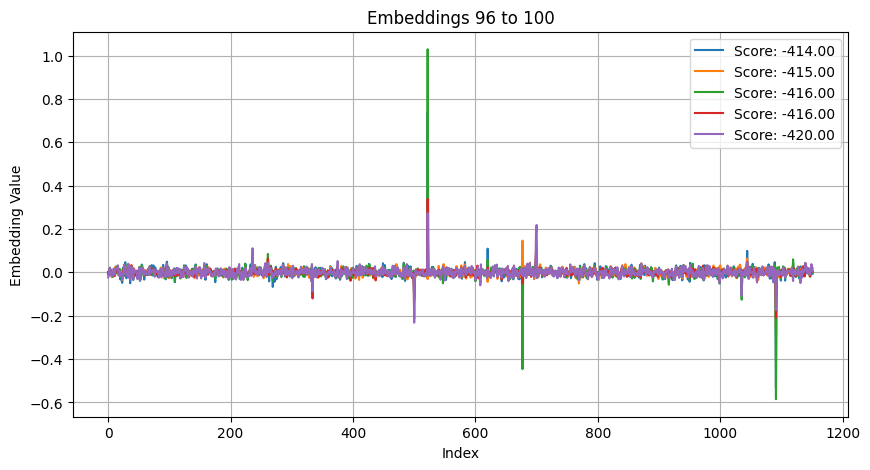

Score: -421.0
Score: -426.0
Score: -426.0
Score: -429.0
Score: -431.0


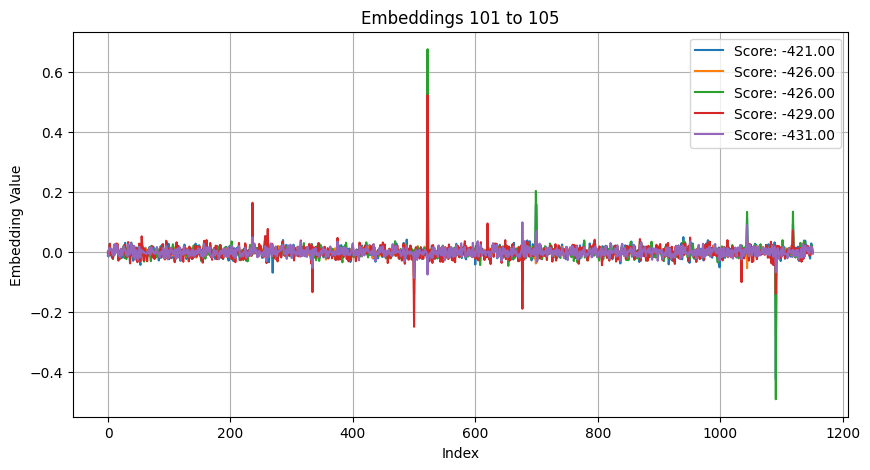

Score: -434.0
Score: -436.0
Score: -439.0
Score: -441.0
Score: -441.0


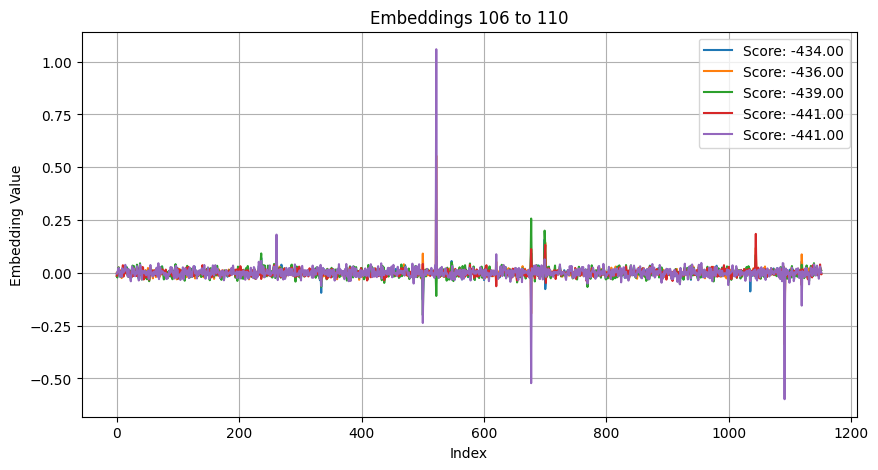

Score: -447.0
Score: -449.0
Score: -451.0
Score: -451.0
Score: -453.0


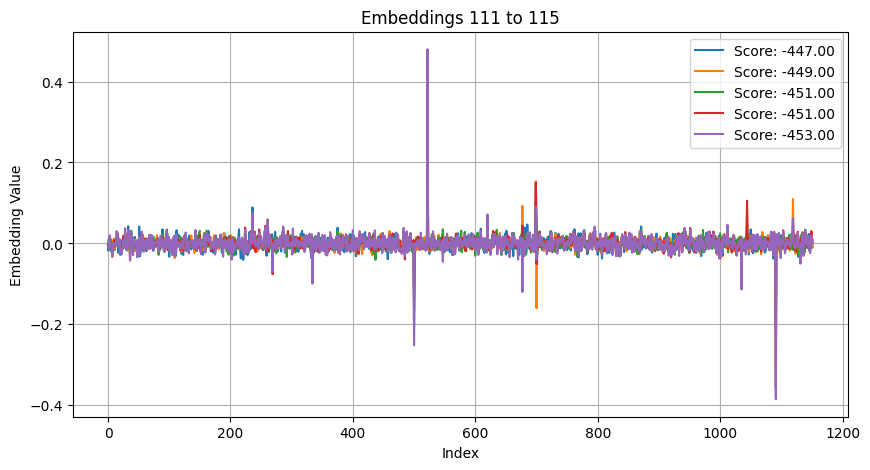

Score: -455.0
Score: -458.0
Score: -461.0
Score: -464.0
Score: -465.0


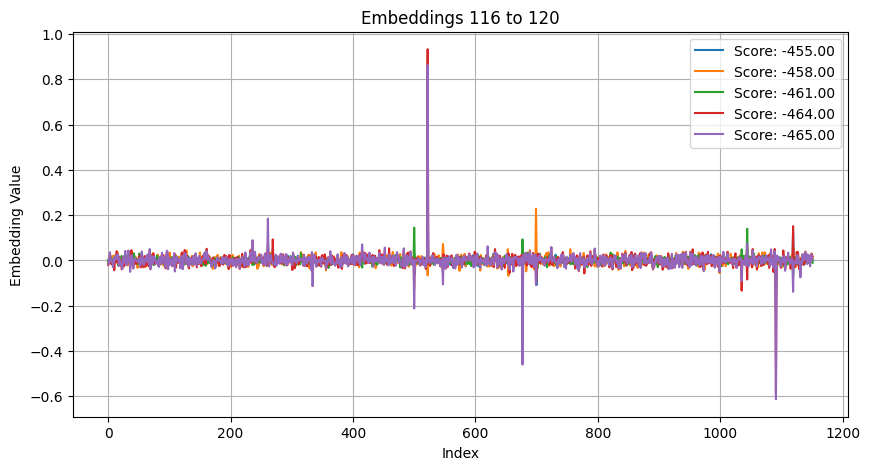

Score: -467.0
Score: -468.0
Score: -468.0
Score: -470.0
Score: -472.0


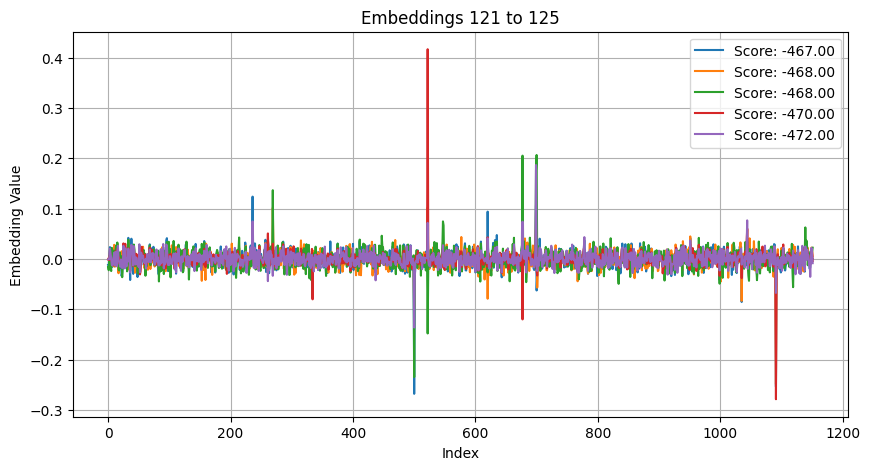

Score: -473.0
Score: -473.0
Score: -476.0
Score: -477.0
Score: -477.0


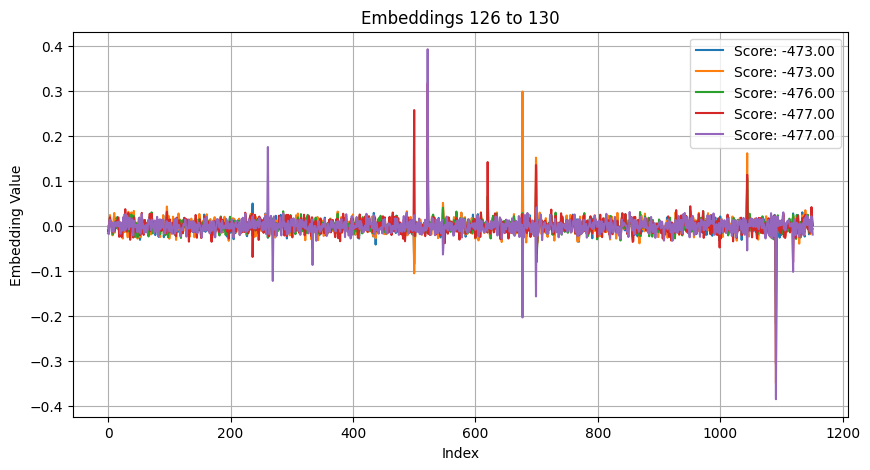

Score: -478.0
Score: -482.0
Score: -483.0
Score: -484.0
Score: -484.0


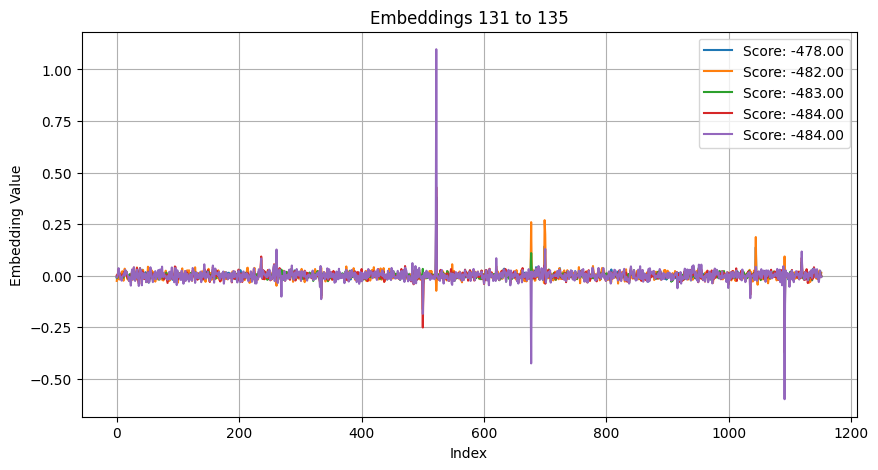

Score: -485.0
Score: -487.0
Score: -488.0
Score: -491.0
Score: -493.0


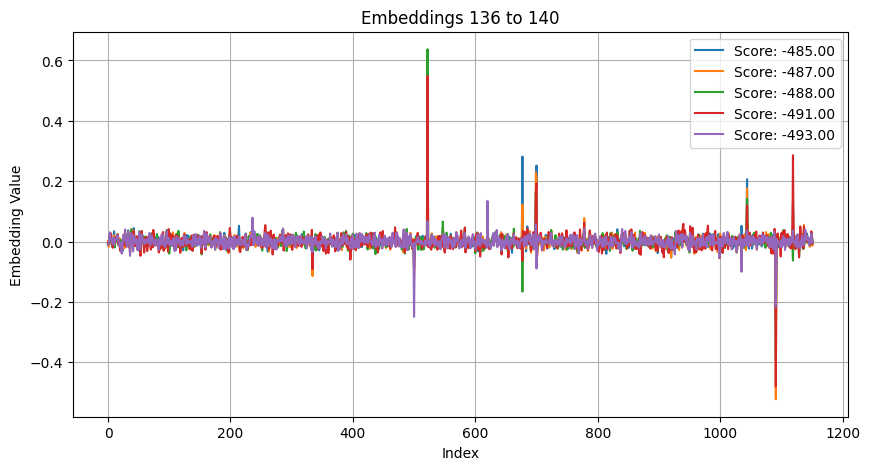

Score: -493.0
Score: -493.0
Score: -493.0
Score: -495.0
Score: -495.0


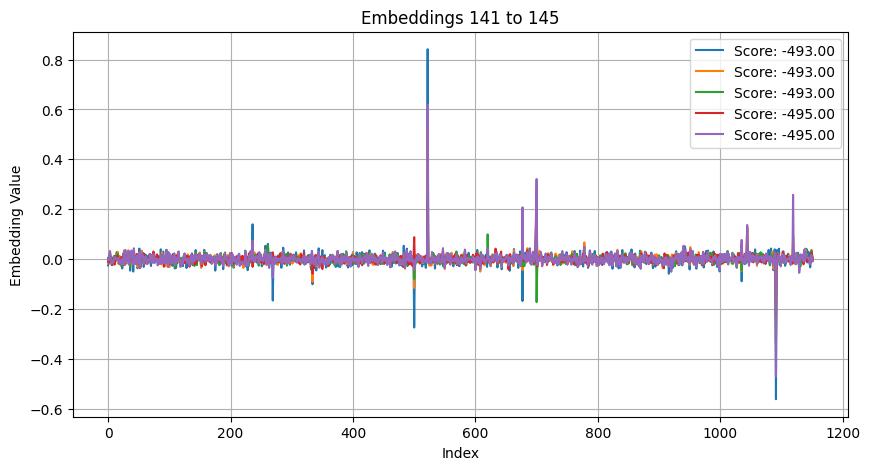

Score: -496.0
Score: -497.0
Score: -497.0
Score: -498.0
Score: -499.0


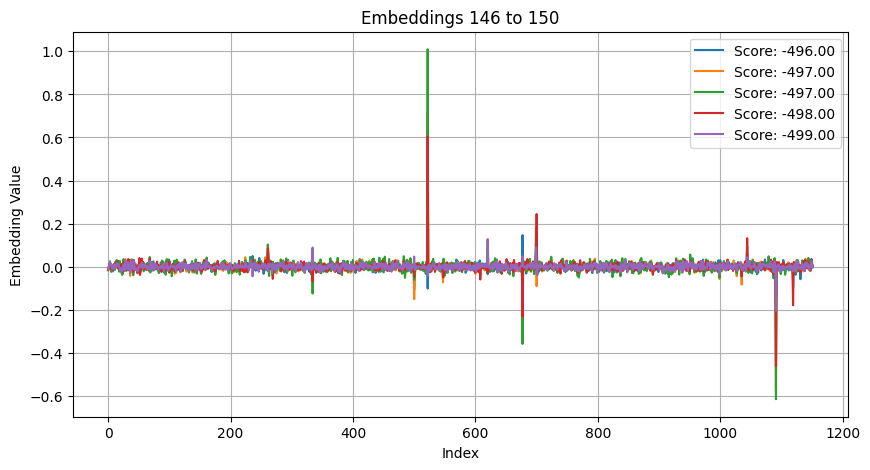

Score: -499.0
Score: -502.0
Score: -502.0
Score: -506.0
Score: -506.0


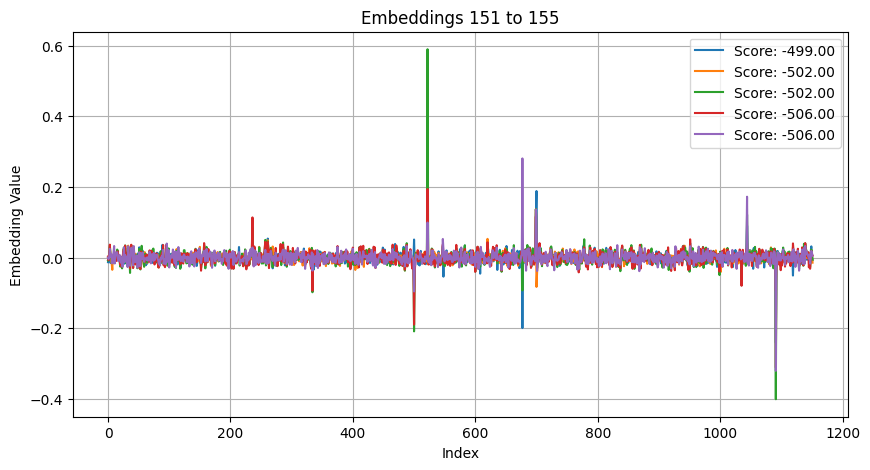

Score: -506.0
Score: -509.0
Score: -511.0
Score: -514.0
Score: -515.0


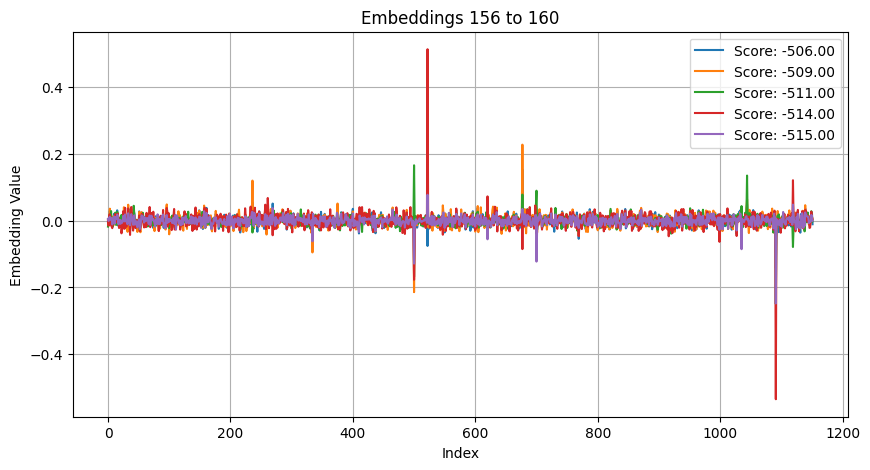

Score: -517.0
Score: -518.0
Score: -519.0
Score: -519.0
Score: -519.0


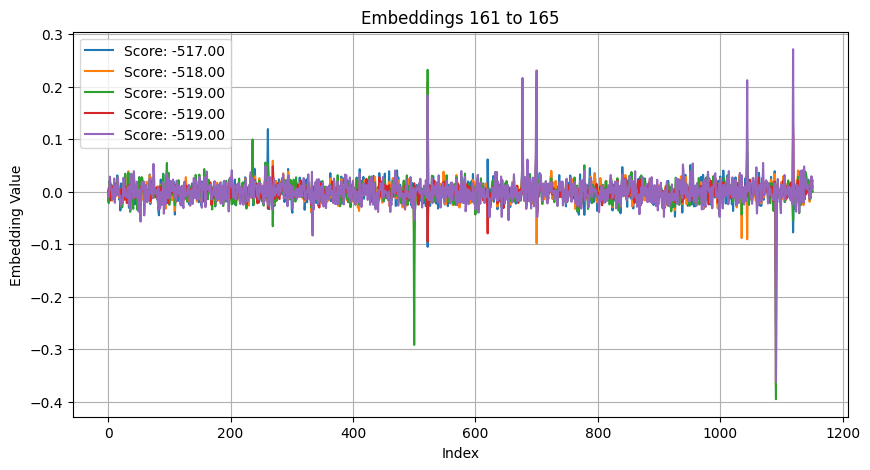

Score: -519.0
Score: -522.0
Score: -523.0
Score: -523.0
Score: -523.0


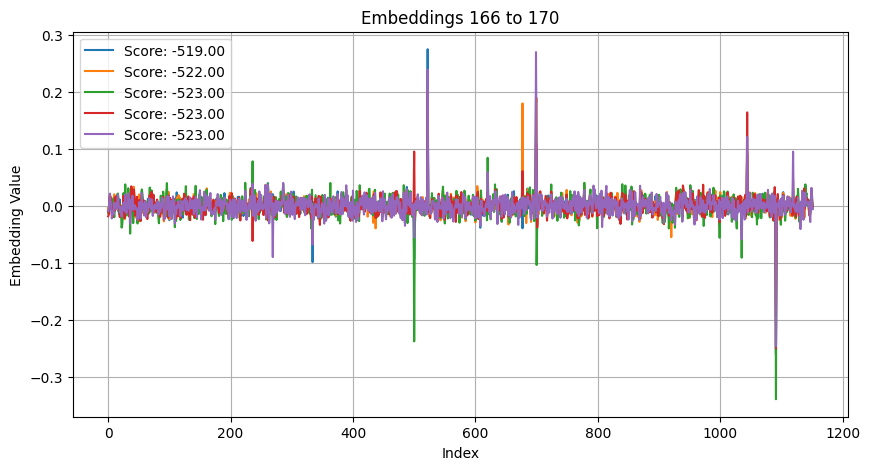

Score: -523.0
Score: -525.0
Score: -526.0
Score: -527.0
Score: -528.0


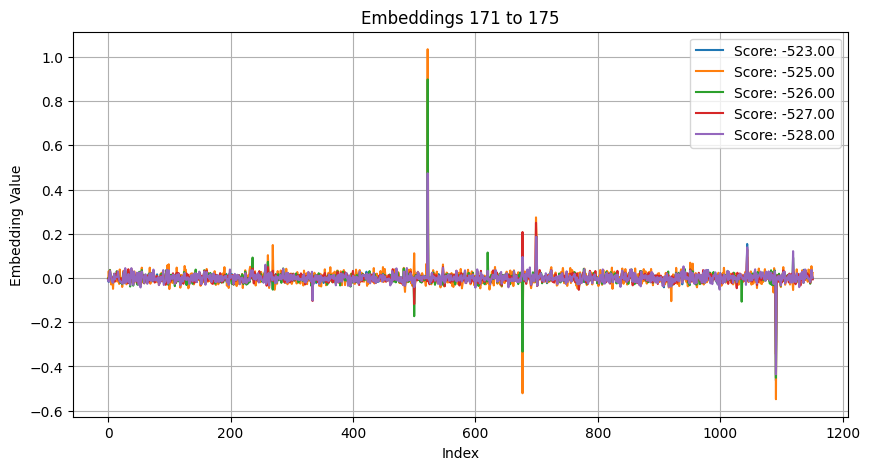

Score: -528.0
Score: -528.0
Score: -531.0
Score: -532.0
Score: -534.0


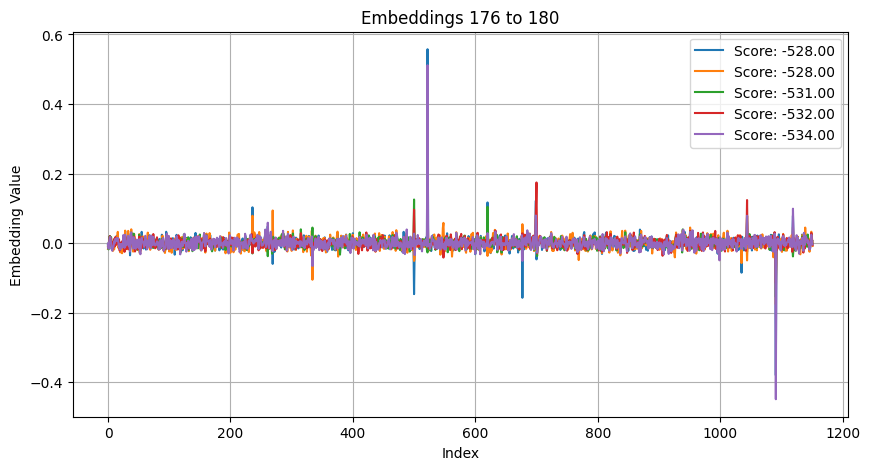

Score: -536.0
Score: -538.0
Score: -539.0
Score: -539.0
Score: -540.0


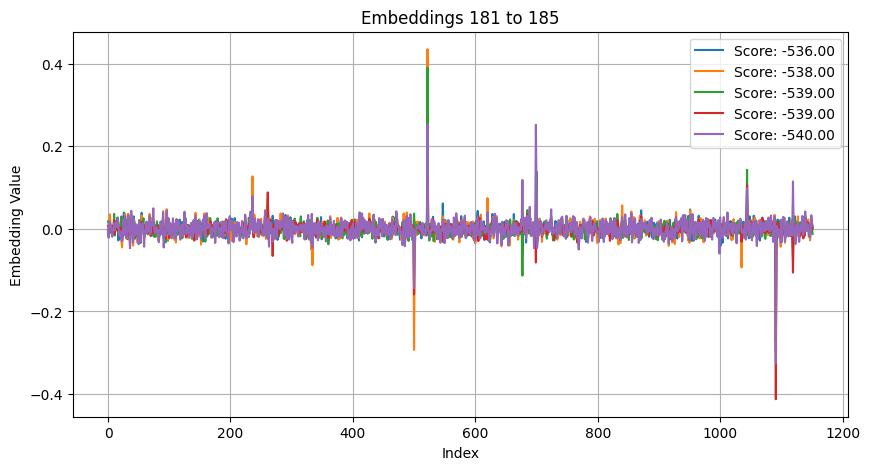

Score: -540.0
Score: -543.0
Score: -545.0
Score: -548.0
Score: -549.0


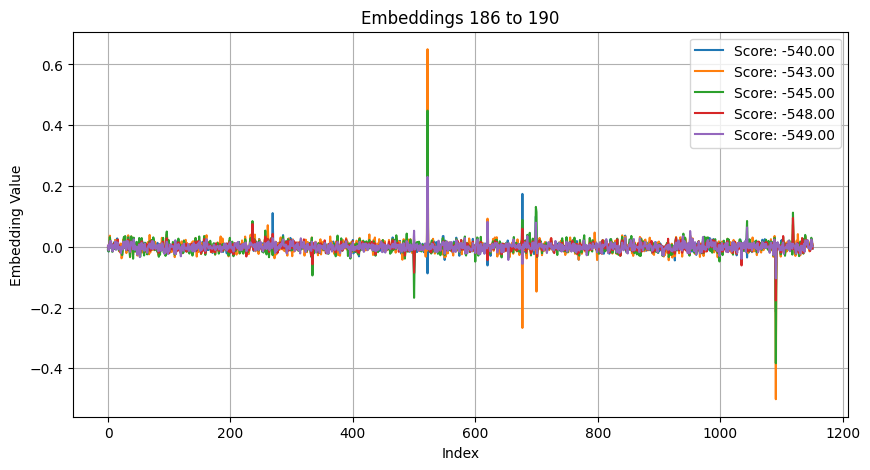

Score: -552.0
Score: -553.0
Score: -571.0
Score: -580.0
Score: -582.0


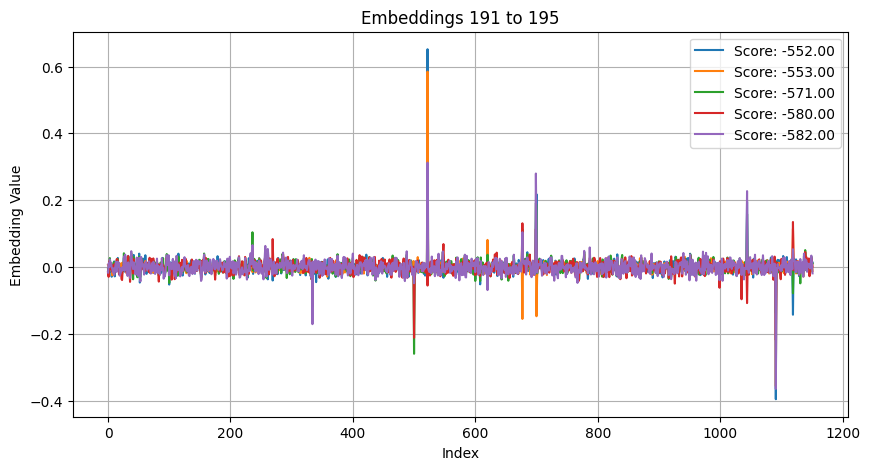

Score: -592.0
Score: -595.0
Score: -613.0
Score: -642.0


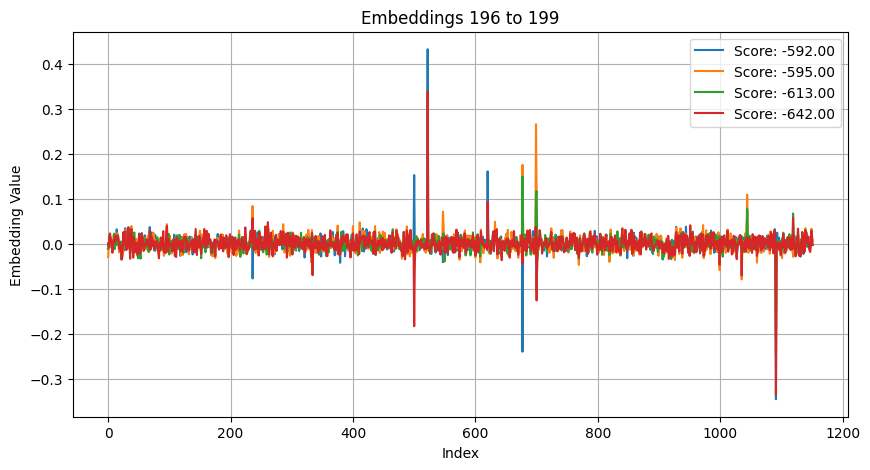

In [ ]:
#now i want to graph the embeds and print out the score for each

top_k = 5  #number of embeddings per graph
for i in range(0, len(score_embed_pairs_sorted), top_k):
    chunk = score_embed_pairs_sorted[i:i+top_k]  # take 5 at a time

    plt.figure(figsize=(10, 5))
    for score, embed in chunk:
        plt.plot(range(len(embed)), embed, label=f"Score: {score:.2f}")
        print("Score:", score)

    plt.xlabel("Index")
    plt.ylabel("Embedding Value")
    plt.title(f"Embeddings {i+1} to {i+len(chunk)}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import re
import pandas as pd

# 1. Define a parser that extracts all variants from the "Natural variant" field
def parse_variants(variant_str):
    if pd.isna(variant_str):  # handles NaN or missing entries
        return []
    # Regex finds: VARIANT [number]; /note="X -> Y"
    pattern = r"VARIANT\s+(\d+).*?\"([A-Z])\s*->\s*([A-Z])"
    matches = re.findall(pattern, variant_str)
    return [(int(pos), orig, new) for pos, orig, new in matches]

# 2. Apply parser across the dataframe
uniprotkb["ParsedVariants"] = uniprotkb["Natural variant"].apply(parse_variants)

uniprotkb = uniprotkb[uniprotkb["Natural variant"].notna()]
uniprotkb

,Entry,Entry Name,Protein names,Gene Names,Organism,Length,Sequence,Polymorphism,Natural variant,ParsedVariants
0,A0A087X1C5,CP2D7_HUMAN,Cytochrome P450 2D7 (EC 1.14.14.1),CYP2D7,Homo sapiens (Human),515,MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,POLYMORPHISM: One study shows that a rare doub...,"VARIANT 70; /note=""S -> N (in dbSNP:rs11090077...","[(70, S, N), (311, S, L), (337, C, C), (369, H..."
2,A0A0C5B5G6,MOTSC_HUMAN,Mitochondrial-derived peptide MOTS-c (Mitochon...,MT-RNR1,Homo sapiens (Human),16,MRWQEMGYIFYPRKLR,NaN,"VARIANT 14; /note=""K -> Q (specific to the Nor...","[(14, K, Q)]"
5,A0A1B0GTW7,CIROP_HUMAN,Ciliated left-right organizer metallopeptidase...,CIROP LMLN2,Homo sapiens (Human),788,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,NaN,"VARIANT 31; /note=""S -> F (in HTX12; uncertain...","[(31, S, F), (191, C, S), (346, S, L), (389, R..."
6,A0AV02,S12A8_HUMAN,Solute carrier family 12 member 8 (Cation-chlo...,SLC12A8 CCC9,Homo sapiens (Human),714,MTQMSQVQELFHEAAQQDALAQPQPWWKTQLFMWEPVLFGTWDGVF...,NaN,"VARIANT 181; /note=""R -> C (in dbSNP:rs2993631...","[(181, R, C), (266, L, P), (281, I, V), (541, ..."
7,A0AV96,RBM47_HUMAN,RNA-binding protein 47 (RNA-binding motif prot...,RBM47,Homo sapiens (Human),593,MTAEDSTAAMSSDSAAGSSAKVPEGVAGAPNEAALLALMERTGYSM...,NaN,"VARIANT 538; /note=""G -> R (in dbSNP:rs3552925...","[(538, G, R), (565, M, V)]"
...,...,...,...,...,...,...,...,...,...,...
20374,Q96M78,FEAS2_HUMAN,Putative uncharacterized protein encoded by FE...,FER1L6-AS2 C8orf78,Homo sapiens (Human),137,MSQVGRVRSSHHFESVCLDAEVRVVLVALDHAGLHTLSSALNESLR...,NaN,"VARIANT 92; /note=""L -> S (in dbSNP:rs13258808...","[(92, L, S)]"
20378,Q96MH7,CE034_HUMAN,Uncharacterized protein C5orf34,C5orf34,Homo sapiens (Human),638,MAAELRMILYEDDSVQVQYVDGSTLQLSPCGSEFLFEKSPPVSAHP...,NaN,"VARIANT 266; /note=""S -> R (in a breast cancer...","[(266, S, R)]"
20380,Q96MT4,CF195_HUMAN,Uncharacterized protein encoded by LINC01600,LINC01600 C6orf195,Homo sapiens (Human),127,MIYPLDLFRNIPWKQGKCFASLSPEGERAFDGMEPLCQPGARPALR...,NaN,"VARIANT 2; /note=""I -> F (in dbSNP:rs17135340)...","[(2, I, F), (43, P, S)]"
20385,Q96T59,CDRTF_HUMAN,CMT1A duplicated region transcript 15 protein,CDRT15,Homo sapiens (Human),188,MFSCCFPTSRGCCFRNGGSESLFRRCRRRLIPHPRRLSPVVIRRIQ...,NaN,"VARIANT 24; /note=""R -> Q (in dbSNP:rs17679866...","[(24, R, Q)]"


In [ ]:
#make a function that passes in a sequence and tuple of the variants (location, original, mutation). Then amino acid a, original and amino acid b, mutation
#Then I think it should be good to make a dictionary where the key is the mutation S -> N or R -> Q or whatever
#the value in the dictionary will be the mutated sequence. every sequence will have 1 mutation
#the idea is to compute the score for every mutated sequence and average them all

def dict_mutations_sequences(sequence, mutations):
  meow = {}
  #mutations are a list of tuples
  for mut in mutations:
    location = mut[0] -1 #subtract 1 to get the index
    original = mut[1]
    newmut = mut[2]

    k = original + newmut

    #create the mutation
    new_seq = list(sequence)
    new_seq[location] = newmut
    #join back together
    new_seq = "".join(new_seq)

    if k not in meow:
      meow[k] = []
      meow[k].append(new_seq)
    else:
      meow[k].append(new_seq)

  return meow

"""
#test
sequence = "ABBBBABBBBBBABBB"
tuples = [(1,"A","B"), (5,"B","C"), (6, "B", "C")]

print(dict_mutations_sequences(sequence, tuples))
"""


'\n#test\nsequence = "ABBBBABBBBBBABBB"\ntuples = [(1,"A","B"), (5,"B","C"), (6, "B", "C")]\n\nprint(dict_mutations_sequences(sequence, tuples))\n'

In [ ]:

#use the function now to pass in the tuples and sequence
#loops through rows and obtains each sequence and tuples of mutations
#list of dictionaries
list_of_dict = []

for i, (index, row) in enumerate(uniprotkb.iterrows()):
    dict_of_cosine_scores = {} #this is not averaged. Key = mutation eg. A->B, value = list of cosine scores
    if i == 3000:
      break
    print(i)
    sequence = row['Sequence'] #this is the original sequence
    ref_embedding = embed_protein(sequence, middle_layer=12)#get the reference embedding
    ref_embedding = ref_embedding['mean']
    mutation_tuples = row['ParsedVariants']
    dict_of_mutated_sequences = dict_mutations_sequences(sequence, mutation_tuples) #returns A->B: [sequence, sequence]

    #now you can loop through the keys and calculate scores
    for key in dict_of_mutated_sequences: #iterate through keys A->B
      list_mutated_sequences = dict_of_mutated_sequences[key]
      for sequ in list_mutated_sequences: #iterate through sequences [sequence, sequence]
        sequ_embedding = embed_protein(sequ, middle_layer=12)
        sequ_embedding = sequ_embedding['mean']
        score = cosine_sim(ref_embedding, sequ_embedding, scale_to_unit=True)
        #once score is obtained, put in dictionary
        if key not in dict_of_cosine_scores:
          dict_of_cosine_scores[key] = []
          dict_of_cosine_scores[key].append(score)
        else:
          dict_of_cosine_scores[key].append(score)

    #once done calculating scores for each sequence in key, put the dictionary in the list_of_dict
    list_of_dict.append(dict_of_cosine_scores)


print(list_of_dict)


In [ ]:
averaged_dict =  {'SN': 0.99977577, 'SL': 0.9997838, 'CC': 0.9999937, 'HR': 0.9993524, 'KE': 0.9995323, 'KQ': 0.99980474, 'SF': 0.9995718, 'CS': 0.99950296, 'RI': 0.99966127, 'LP': 0.9990132, 'RC': 0.99920106, 'IV': 0.99995744, 'KR': 0.9998786, 'RQ': 0.9996591, 'GR': 0.99919236, 'MV': 0.9998872, 'NS': 0.99981034, 'DN': 0.99966544, 'PL': 0.99963415, 'LI': 0.9999305, 'AT': 0.999835, 'SG': 0.9998483, 'PQ': 0.9998118, 'TS': 0.99993056, 'ML': 0.9999551, 'HD': 0.9996039, 'ND': 0.99977225, 'DG': 0.9994209, 'QE': 0.99986345, 'MK': 0.9994788, 'NY': 0.9997101, 'AV': 0.999821, 'HY': 0.99967194, 'LV': 0.99988425, 'TK': 0.99963695, 'PS': 0.9998751, 'ED': 0.9999234, 'LF': 0.99986494, 'CR': 0.9992867, 'TA': 0.999892, 'IT': 0.99978024, 'DA': 0.9996939, 'VD': 0.99931216, 'RK': 0.99991584, 'DE': 0.99981225, 'RH': 0.9996283, 'RW': 0.99934196, 'KT': 0.9998718, 'EK': 0.99938464, 'YF': 0.99994415, 'TI': 0.9997052, 'TM': 0.9998336, 'DY': 0.9994793, 'WR': 0.99923635, 'SP': 0.99976426, 'GS': 0.99976164, 'IS': 0.99970907, 'HP': 0.9995534, 'PH': 0.99966985, 'VF': 0.99963146, 'LR': 0.9989175, 'VL': 0.99982595, 'CY': 0.9993147, 'GV': 0.9995008, 'RS': 0.9996437, 'NT': 0.9997597, 'QR': 0.9996503, 'EQ': 0.9998142, 'MT': 0.9998422, 'SY': 0.99985415, 'AP': 0.99922764, 'VM': 0.99988127, 'PR': 0.99944353, 'CW': 0.9992937, 'SI': 0.999714, 'QH': 0.9999187, 'RG': 0.9995539, 'GC': 0.9994764, 'TN': 0.99984014, 'GA': 0.99968, 'MR': 0.9991798, 'AD': 0.9994863, 'YC': 0.9994284, 'YH': 0.9997984, 'GE': 0.99927646, 'VI': 0.9999099, 'WL': 0.9996926, 'MI': 0.99990374, 'TP': 0.999413, 'IL': 0.99992585, 'HN': 0.9997498, 'AS': 0.9999104, 'PA': 0.9999001, 'IN': 0.99946874, 'GD': 0.99928504, 'VA': 0.9998543, 'SR': 0.9993442, 'LS': 0.9992541, 'RP': 0.9990571, 'WG': 0.99972737, 'FS': 0.9993909, 'YD': 0.9994767, 'PT': 0.99990284, 'FI': 0.9997552, 'IM': 0.99985343, 'FL': 0.999785, 'SC': 0.99973106, 'IF': 0.99983954, 'SS': 1.0, 'EG': 0.9996565, 'NH': 0.9998002, 'FV': 0.9997615, 'AG': 0.9999106, 'WS': 0.9991817, 'QL': 0.9997, 'DV': 0.9993419, 'KN': 0.999798, 'QP': 0.99945176, 'NK': 0.9997502, 'HQ': 0.99968576, 'CG': 0.99922556, 'EA': 0.99963737, 'ST': 0.99994504, 'LW': 0.9998972, 'FY': 0.99993473, 'VE': 0.99961, 'EV': 0.99971116, 'HL': 0.99974686, 'RT': 0.9997231, 'QK': 0.99951303, 'DH': 0.99955016, 'AE': 0.99940157, 'YN': 0.99980515, 'RL': 0.9994621, 'VG': 0.99956685, 'FC': 0.99960905, 'IK': 0.9990774, 'KI': 0.9995249, 'CF': 0.99932146, 'SW': 0.99950725, 'QQ': 0.99999994, 'AQ': 0.9999094, 'TR': 0.9994816, 'WC': 0.9995188, 'GW': 0.9993845, 'AA': 1.0, 'SA': 0.9999229, 'LL': 0.99995285, 'RM': 0.9997888, 'LQ': 0.9996315, 'NI': 0.9993291, 'LM': 0.99985284, 'YS': 0.9996909, 'RR': 1.0, 'PW': 0.99983907, 'ID': 0.9996713, 'VH': 0.99980193, 'TT': 1.0, 'LH': 0.99937326, 'VV': 0.99999523, 'IR': 0.9996861, 'KM': 0.99977106, 'AN': 0.99997437, 'II': 0.9999833, 'MM': 1.0, 'PP': 1.0, 'DD': 1.0, 'KL': 0.99992955, 'LY': 0.9997045, 'FF': 1.0, 'WQ': 0.99991584, 'YR': 0.9998819, 'EH': 0.99979806, 'YY': 1.0, 'EE': 1.0, 'AI': 0.99967045, 'AK': 0.9998313, 'EM': 0.9998783, 'DF': 0.99953103, 'HH': 1.0, 'AF': 0.9999191, 'RN': 0.999935, 'IY': 0.99998647, 'KK': 0.99996704, 'GG': 0.9997852, 'EC': 0.9996735, 'SD': 0.99996376, 'EN': 0.999897, 'KD': 0.99822074, 'ET': 0.99989825, 'NE': 0.99994785, 'YM': 0.9998824, 'AR': 0.9998824, 'QN': 0.9998997, 'QS': 0.9999556, 'LA': 0.99980885, 'CK': 0.99940574, 'CQ': 0.9994562, 'FG': 0.999753, 'LT': 0.9998217, 'WE': 0.999774, 'WK': 0.9998156, 'QY': 0.9998536, 'PD': 0.9998651, 'PG': 0.9998949, 'PV': 0.9998079, 'RF': 0.99986964, 'RY': 0.9998743, 'YG': 0.9997279, 'YL': 0.99987644, 'DS': 0.99990743, 'QD': 0.9998025, 'AL': 0.999086, 'YV': 0.9993218, 'YI': 0.99980533, 'RE': 0.99950385, 'TD': 0.9999094, 'ES': 0.99987435, 'TG': 0.9998716, 'GT': 0.99991506, 'GL': 0.99987334, 'LE': 0.9997794, 'HC': 0.999897, 'DR': 0.99961126, 'FA': 0.99984974, 'FT': 0.9998084, 'QG': 0.9998697, 'ER': 0.999837, 'EW': 0.99981546, 'TE': 0.99991703, 'FD': 0.9998237, 'FH': 0.9998701, 'GN': 0.9998597, 'PC': 0.99978995, 'KW': 0.99979067, 'CT': 0.9999522, 'CA': 0.9999429, 'PF': 0.99984574, 'TH': 0.9999515, 'VQ': 0.99878484, 'NG': 0.9997776, 'PM': 0.99963534, 'SV': 0.999991, 'NN': 1.0, 'LD': 0.999833, 'TL': 0.99989986, 'LC': 0.9997822, 'CH': 0.99982446, 'DI': 0.99995357, 'VN': 0.99986607, 'EL': 0.9999341, 'AM': 0.999848, 'MQ': 0.9999098, 'HT': 0.99982727, 'VT': 0.9999926, 'MS': 0.9956485, 'GQ': 0.9999813, 'WW': 1.0000001, 'IP': 0.99997526, 'YW': 0.99984163, 'LG': 0.9963094, 'AC': 0.9999073, 'MN': 0.9997306, 'KA': 0.9999543}


Text(0, 0.5, 'blosum')

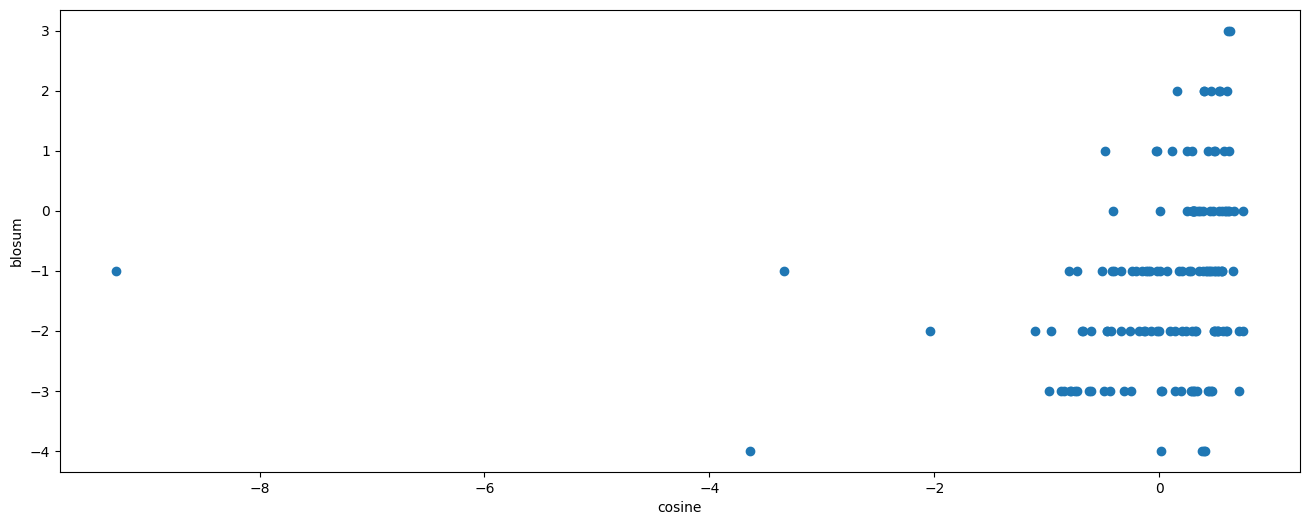

In [ ]:
!pip install biopython
from Bio.Align import substitution_matrices
blosum62 = substitution_matrices.load("BLOSUM62")

collapsed_dict = {}
for key, value in averaged_dict.items():
    aa1, aa2 = key[0], key[1]
    if aa1 == aa2:
        continue
    unordered = "".join(sorted([aa1, aa2])) #forces amino acid pairs to be ordered alphabetically
    collapsed_dict.setdefault(unordered, []).append(value)

collapsed_dict = {k: np.mean(v) for k, v in collapsed_dict.items()} #take mean of that new list

#Normalize
cosine_scores = np.array(list(collapsed_dict.values()))
cos_mean = cosine_scores.mean()
cos_std = cosine_scores.std()
# cos_min, cos_max = cosine_scores.min(), cosine_scores.max()
# collapsed_dict = {k: (v - cos_min) / (cos_max - cos_min) for k, v in collapsed_dict.items()}
collapsed_dict = {k: (v - cos_mean) / (cos_std) for k, v in collapsed_dict.items()}


pairs = []
cosine_vals = []
blosum_vals = []

for key, cos_score in collapsed_dict.items(): #pair em up
    aa1, aa2 = key[0], key[1]
    try:
        blosum_score = blosum62[aa1, aa2]
    except KeyError:
        continue
    pairs.append(key)
    cosine_vals.append(cos_score)
    blosum_vals.append(blosum_score)

plt.figure(figsize=(16,6))

plt.scatter(cosine_vals, blosum_vals)
plt.xlabel("cosine")
plt.ylabel("blosum")

In [ ]:
from scipy import stats

#pearson correlation
corr = np.corrcoef(cosine_vals, blosum_vals)[0,1]
print("Correlation:", corr)

#spearman correlation
correlation_coefficient = stats.spearmanr(cosine_vals, blosum_vals)
print(correlation_coefficient)



Correlation: 0.19991122670798508
SignificanceResult(statistic=0.35710104144908783, pvalue=9.663986611502735e-06)


In [ ]:
import numpy as np
import scipy.stats as st

# compute Pearson correlation
r, _ = st.spearmanr(cosine_vals, blosum_vals)

# Fisher z-transform
n = len(cosine_vals)
z = np.arctanh(r)  # atanh is inverse tanh
se = 1 / np.sqrt(n - 3)  # standard error
z_crit = st.norm.ppf(0.995)  # 99% CI

# confidence interval in z-space, then back-transform
lo_z, hi_z = z - z_crit*se, z + z_crit*se
lo, hi = np.tanh([lo_z, hi_z])

print(f"Correlation: r = {r:.3f}")
print(f"99% CI: [{lo:.3f}, {hi:.3f}]")


Correlation: r = 0.357
99% CI: [0.157, 0.529]


In [ ]:
# mutate at every position with every possible amino acid
def mutate_a_lot(s):
    mutations = []
    aa = ["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I",
          "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"]

    for i in range(len(s)):
        for a in aa:
            if a != s[i]:
                new_s = s[:i] + a + s[i+1:]
                mutations.append(new_s)

    return mutations

seq_mut ={} #key is original sequence, value is list of mutated sequences
for i in range(10):
  sequence = uniprotkb["Sequence"][i]
  seq_mut[sequence] = mutate_a_lot(sequence)

#generate embeds for each of them
list_of_tuple = []
for key in seq_mut:
  embeds = []
  ref_embed = embed_protein(key, middle_layer = 12)

  listseq = seq_mut[key]
  for seq in listseq:
    embeds.append(embed_protein(seq, middle_layer = 12))

  list_of_tuple.append((ref_embed,embeds))


print(list_of_tuple)